In [1]:
import mlflow
import pandas as pd
mlflow.set_tracking_uri('../mlruns')
experiment_id = "914879025403898454"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import math

def plot_alpha_vs_aee_with_runtime(
    runs_data,
    metric='mean_aee_target_attack_step_',
    eps_to_plot=None
):
    """
    Плoт Mean AEE vs iterations для каждого epsilon в динамической сетке субплотов.
    Если eps_to_plot задан, строится только график для этого epsilon.
    Легенда показывает реальное время выполнения в секундах.
    """
    # 1) Валидация и копия
    if not isinstance(runs_data, pd.DataFrame):
        raise ValueError("runs_data must be a pandas DataFrame")
    df = runs_data.copy()

    # 2) Длительности
    if 'start_time' not in df or 'end_time' not in df:
        raise KeyError("runs_data must include 'start_time' & 'end_time'")
    df['start_ts'] = pd.to_datetime(df['start_time'], unit='ms')
    df['end_ts']   = pd.to_datetime(df['end_time'],   unit='ms')
    df['duration_s'] = (df['end_ts'] - df['start_ts']).dt.total_seconds()

    # 3) Приведение типов
    df["params.alpha"]         = df["params.alpha"].astype(float)
    df["params.epsilon"]       = df["params.epsilon"].astype(float)
    df["params.use_map_scaling"]= df["params.use_map_scaling"].astype(bool)
    df["params.num_samples"]   = df["params.num_samples"].astype(int)

    # 4) Фильтрация по eps, если нужно
    if eps_to_plot is not None:
        df = df[df["params.epsilon"] == float(eps_to_plot)]
        if df.empty:
            raise ValueError(f"No runs with epsilon={eps_to_plot}")

    # 5) Список уникальных eps
    eps_list = sorted(df["params.epsilon"].unique())
    m = len(eps_list)

    # 6) Динамика сетки
    nrows = math.floor(math.sqrt(m)) or 1
    ncols = math.ceil(m / nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    # приводим axes к списку
    if m == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # 7) Отрисовка каждого графика
    eps_map   = {0.00392:'1/255',0.00784:'2/255',0.01568:'4/255',0.03137:'8/255'}
    layers    = sorted(df["params.num_samples"].unique())
    colors    = plt.cm.viridis(np.linspace(0, 1, len(layers)))
    color_map = dict(zip(layers, colors))
    marker_map= {True:'s', False:'o'}

    # Определение метки оси Y
    if "target" in metric:
        metric_label = "target flow"
    elif "init" in metric:
        metric_label = "initial flow"
    else:
        metric_label = metric.replace("_"," ")

    for ax, eps in zip(axes, eps_list):
        group = df[df["params.epsilon"] == eps]
        eps_frac = eps_map.get(eps, str(eps))
        ax.set_title(f"Epsilon: {eps_frac}", fontsize=14)
        ax.set_xlabel("Iterations", fontsize=12)
        ax.set_ylabel(f"Mean AEE ({metric_label})", fontsize=12)

        for _, row in group.iterrows():
            # собираем AEE по шагам
            aee = {}
            for col, val in row.items():
                if col.startswith('metrics.'+metric):
                    step = int(re.search(r'(\d+)$', col).group(1))
                    aee[step] = val
            steps = sorted(aee)
            vals  = [aee[s] for s in steps]
            dur   = row['duration_s']
            label = f"{row['params.attack_type']} / {row['params.num_samples']} ({dur/32:.1f}s)"

            ax.plot(steps, vals,
                    linestyle='-',
                    marker=marker_map[row["params.use_map_scaling"]],
                    color=color_map[row["params.num_samples"]],
                    markersize=6,
                    label=label)

        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


In [7]:
vmi_fgsm = ["689e19ee91fb4d6a806dc9eb7fa0878f","0b1382b9efb94db4aef9902fc7842f3f","a32b1a4bde96449e8d6c43236ee1c408","d97601a89d58418aa9390c79b6bc544b","6c5363aa11ce46f9804b9163a162cc6a","a94d336f9fdb4903b58c667b1fbf0693","8c7fabf29f564cdf9f1be357aa7d1ebf","36c4f913f8964d86a29d1d964dfdbebf","e381ca7f70f14e6bb9a87c98c25c5f28","4d5e1042519740b1a6696649bd0d5f39","b29293b58c62498cbbaa1c151595a267","dd8f32c469784d0eb9627d22b0369e59","93f8d528a19343e48315390bfb2f5861","40bee5cc354c44eab48182f3ed0c94bf","c1e5cd822572448fb0ea4aa79284b02f","d3461e28f8c649d8a7797a894ed932b9","95b7248336f846e0a0bf448e52567771","fc0363ad0d5c42a881ffbd1110647937","14deb3be9a41481cb3361a23b325aabd","c0bc3881281147a084d3e879a47c2832","3961d897171948dc8149416993210a25","500499aa6cc944cdb7e6a82107fb8207","15ffb4fe6c7d4d55b5badc695ed84d0c","b4eddd8c47d34701bc4a72b54d4d53aa"]
old_mifgsm = ["bd47324e647a4790bbc949b06947b2f2","dec0eb80cc0e4b85b1141ac5ecb88a9c","58d7a0c23a8a473a9f59e9c6a1fa762d","fbae4878498e4b35a717df90c1248a8c"]
ids_str = ", ".join(f"'{run}'" for run in vmi_fgsm+old_mifgsm)
# Формируем финальный запрос
filter_string = f"attributes.run_id IN ({ids_str})"
runs = mlflow.search_runs(
    experiment_ids=[experiment_id], filter_string=filter_string)
runs['params.num_samples'].fillna('0', inplace=True)

In [8]:
runs['params.epsilon'] = runs['params.epsilon'].astype(float)
runs['params.epsilon'] = runs['params.epsilon'].round(5)
runs.loc[runs['params.attack_type']=='MIFGSM','params.num_samples'] = '0'

In [9]:
runs['params.epsilon']

0     0.03137
1     0.03137
2     0.03137
3     0.03137
4     0.03137
5     0.03137
6     0.01568
7     0.01568
8     0.01568
9     0.01568
10    0.01568
11    0.01568
12    0.00784
13    0.00784
14    0.00784
15    0.00784
16    0.00784
17    0.00784
18    0.00392
19    0.00392
20    0.00392
21    0.00392
22    0.00392
23    0.00392
24    0.03137
25    0.01568
26    0.00784
27    0.00392
Name: params.epsilon, dtype: float64

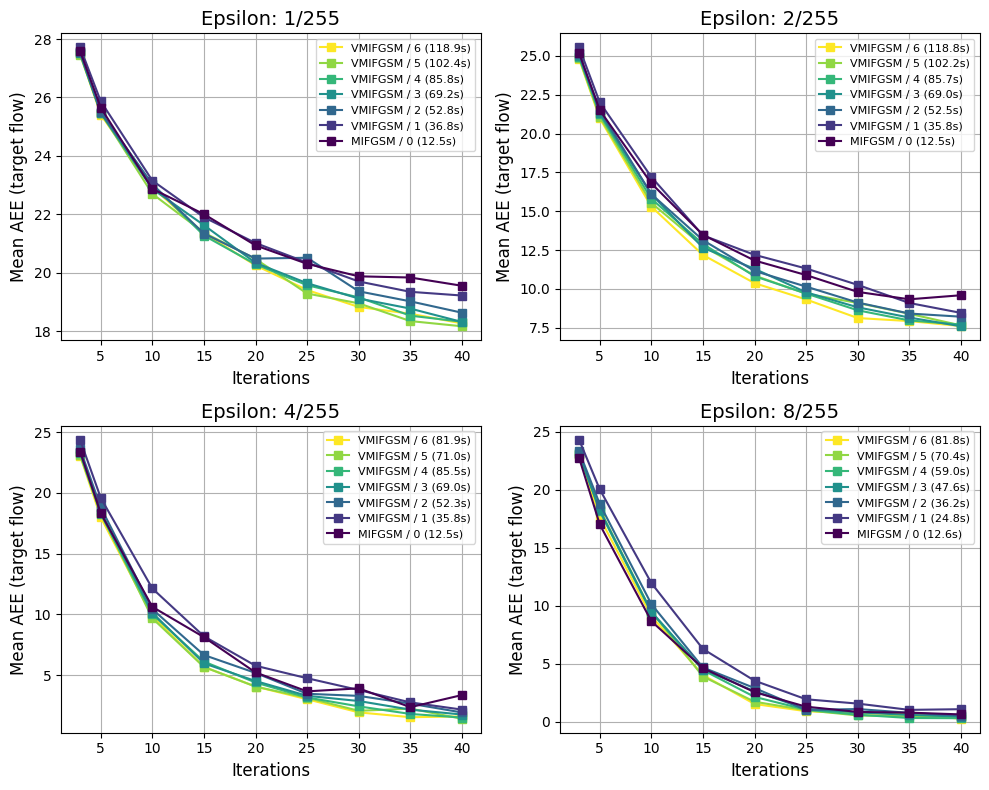

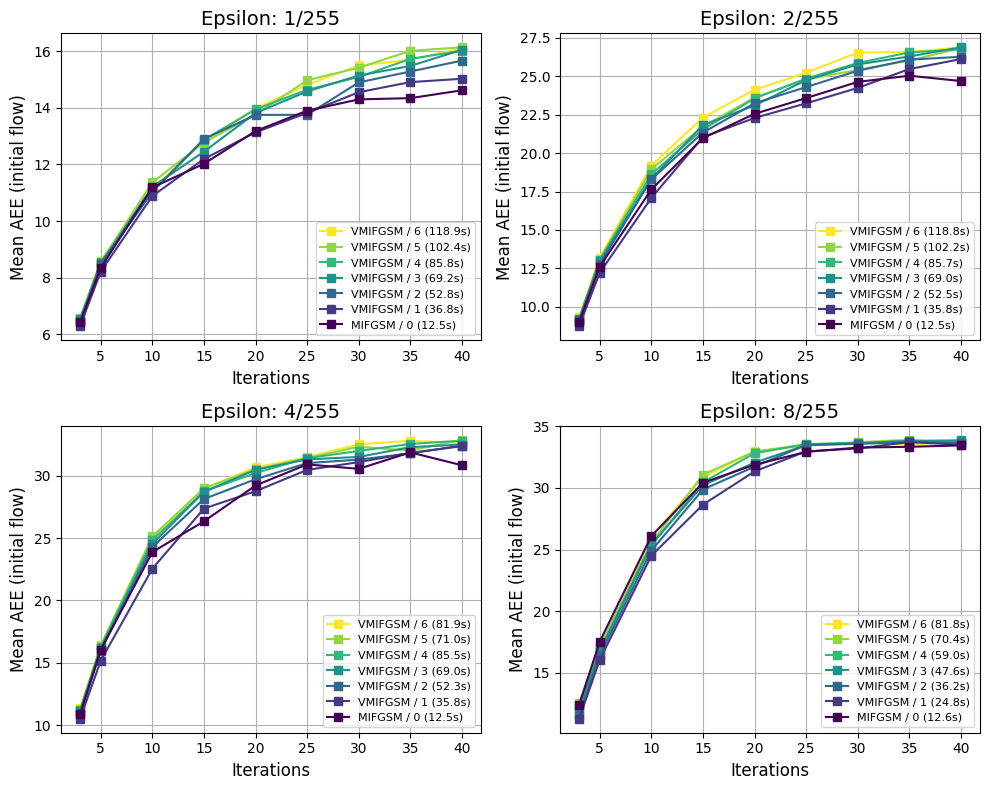

In [10]:
plot_alpha_vs_aee_with_runtime(runs)
plot_alpha_vs_aee_with_runtime(runs, 'mean_aee_init_attack_step_')